In [64]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

height, width = image_gray.shape

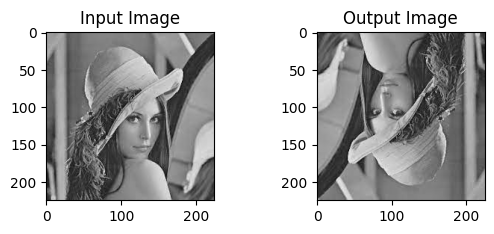

In [65]:
flippped = np.zeros((height,width))

rotated_image = image_gray.copy()

rows = len(rotated_image)
cols = len(rotated_image[0])

rotated_image = [[0 for _ in range(rows)] for _ in range(cols)]


for i in range(rows):
    for j in range(cols):
        rotated_image[j][rows - 1 - i] = image_gray[i][j]
        rotated_image[j][rows - 1 - i] = image_gray[i][j]

test = rotated_image.copy()
rows = len(test)
cols = len(test[0])

rotated_image = [[0 for _ in range(rows)] for _ in range(cols)]

for i in range(rows):
    for j in range(cols):
        rotated_image[j][rows - 1 - i] = test[i][j]

plt.subplot(2,2,1)
plt.title("Input Image")
plt.imshow(image_gray, cmap='gray')

plt.subplot(2,2,2)
plt.title("Output Image")
plt.imshow(rotated_image, cmap='gray')


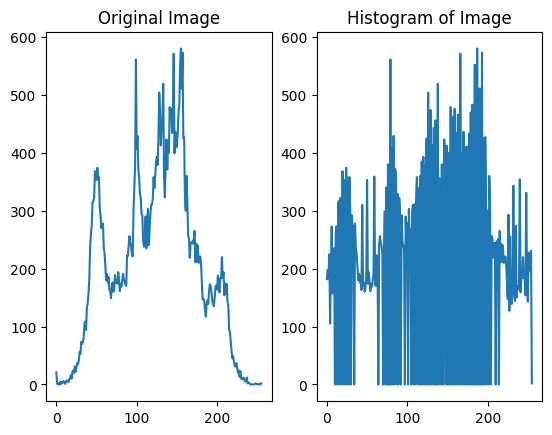

In [66]:
highest_pixel = np.max(rotated_image)
L = np.ceil(np.log2(highest_pixel))

two_to_the_power_l = 2**L
hist = np.zeros(int(two_to_the_power_l))

for i in range(height):
    for j in range(width):
        pixel = image_gray[i,j]
        hist[pixel]+=1

total_pixels = width*height
pdf = []
for i in hist:
    pdf.append(i/total_pixels)

cdf = []
for index,i in enumerate(pdf):
    if index ==0:
        cdf.append(pdf[0])
        continue
    cdf.append( pdf[index]+cdf[index-1] )

normalized_cdf = []
for i in cdf:
    normalized_cdf.append(int(i*(two_to_the_power_l-1)))

equalized = np.zeros((height,width), dtype=np.uint8)
for i in range(height):
    for j in range(width):
        equalized[i,j] = normalized_cdf[image_gray[i,j]]


hist_eq = np.zeros(256)

for i in range(height):
    for j in range(width):
        pixel = equalized[i, j]
        hist_eq[pixel] += 1


plt.subplot(1,2,1)
plt.title("Original Image")
plt.plot(hist)

plt.subplot(1,2,2)
plt.title("Histogram of Image")
plt.plot(hist_eq)


plt.show()